# Data Exploration and Visualisation

Author: Mateo Jakšić

Warsaw, June 2026.

## Prerequisites

We need to import libraries and modules.

In [77]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy.io import arff, loadmat

from sklearn.preprocessing import StandardScaler, RobustScaler

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN

!pip install deadwood
import deadwood

from sklearn.model_selection import ParameterGrid
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

## Data Loading and Processing

We need fuctions for data loading, depending on the file type.

In [ ]:
def load_mat_dataset(path):
    data = loadmat(path)

    X = data["X"]
    y = data["y"].ravel()

    X = StandardScaler().fit_transform(X)

    return X, y

In [ ]:
def load_2d_dataset(data_path, labels_path):
    X = pd.read_csv(data_path, sep=r"\s+", header=None).values
    y_cluster = pd.read_csv(labels_path, sep=r"\s+", header=None).values.ravel()

    y = (y_cluster == 0).astype(int)

    X = StandardScaler().fit_transform(X)

    return X, y

### Outlier Detection DataSets (ODDS)

We are going to load 4 ODDS datasets. They were chosen because of their diversity in number of points, dimensions and percentage of outliers.

A. Cardiotocography dataset (Cardio)

*   1831 points
*   21 dimensions
*   176 (9.6%) outliers
*   UCI machine learning repository

B.  Ionosphere dataset (Ionosphere)

*   351 points
*   33 dimensions
*   126 (36.0%) outliers
*   UCI machine learning repository

C.  Speech dataset (Speech)

*   3686 points
*   400 dimensions
*   61 (1.65%) outliers
*   Speech Processing Group at Brno University of Technology, Czech Republic

D. Japanese Vowels dataset (Vowels)

*   1456 points
*   12 dimensions
*   50 (3.4%) outliers
*   UCI machine learning repository

In [ ]:
datasets = {
    "cardio": "datasets/cardio.mat",
    "ionosphere": "datasets/ionosphere.mat",
    "speech": "datasets/speech.mat",
    "vowels": "datasets/vowels.mat"
}

In [ ]:
for name, path in datasets.items():
    X, y = load_mat_dataset(path)

    outliers = np.sum(y == 1)

    print(
        f"{name}\n"
        f"   Points = {X.shape[0]}\n"
        f"   Dimensions = {X.shape[1]}\n"
        f"   Outliers = {outliers} ({100*outliers/len(y):.2f}%)\n"
    )

cardio
   Points = 1831
   Dimensions = 21
   Outliers = 176 (9.61%)

ionosphere
   Points = 351
   Dimensions = 33
   Outliers = 126 (35.90%)

speech
   Points = 3686
   Dimensions = 400
   Outliers = 61 (1.65%)

vowels
   Points = 1456
   Dimensions = 12
   Outliers = 50 (3.43%)



### Benchmark Suite for Clustering Algorithms

We are going to download 4 datasets. They were chosen from `sipu` and `graves` groups of datasets because `sipu` datasets have interesting visualization and `graves` datasets have noise points.

A. Aggregation dataset (aggregation)

* 788 points
* 0 outliers (0.0%)

B. Flame dataset (flame)

* 240 points
* 12 outliers (5.0%)
* label1

C. Ring outlier (ring)

* 1030 points
* 30 outliers (2.91%)
* label1

D. Zigzag outlier (zigzag)

* 280 points
* 30 outliers (10.71%)
* label1

In [ ]:
datasets_2d = {
    "aggregation": {
        "data": "datasets_2d/aggregation.data.gz",
        "labels": "datasets_2d/aggregation.labels0.gz"
    },
    "flame": {
        "data": "datasets_2d/flame.data.gz",
        "labels": "datasets_2d/flame.labels1.gz"
    },
    "ring": {
        "data": "datasets_2d/ring_outliers.data.gz",
        "labels": "datasets_2d/ring_outliers.labels1.gz"
    },
    "zigzag": {
        "data": "datasets_2d/zigzag_outliers.data.gz",
        "labels": "datasets_2d/zigzag_outliers.labels1.gz"
    }
}

In [ ]:
for name, info in datasets_2d.items():
    X, y = load_2d_dataset(info["data"], info["labels"])

    outliers = np.sum(y == 1)

    print(
        f"{name}\n"
        f"   Points = {X.shape[0]}\n"
        f"   Dimensions = {X.shape[1]}\n"
        f"   Outliers = {outliers} ({100*outliers/len(y):.2f}%)\n"
    )

aggregation
   Points = 788
   Dimensions = 2
   Outliers = 0 (0.00%)

flame
   Points = 240
   Dimensions = 2
   Outliers = 12 (5.00%)

ring
   Points = 1030
   Dimensions = 2
   Outliers = 30 (2.91%)

zigzag
   Points = 280
   Dimensions = 2
   Outliers = 30 (10.71%)



## Algorithms

We are going to use following methods:

A. One-Class SVM

B. Isolation Forest

C. Local Outlier Factor

D. DBSCAN

E. Deadwood

### One-Class SVM

In [ ]:
def run_ocsvm(X, nu=0.05, gamma="scale", kernel="rbf"):
    model = OneClassSVM(nu=nu, gamma=gamma, kernel=kernel)
    model.fit(X)
    scores = -model.score_samples(X)
    preds = model.predict(X)
    preds = (preds == -1).astype(int)
    return scores, preds

### Isolation Forest

In [ ]:
def run_isofor(X, contamination=0.05, n_estimators=300, random_state=42):
    model = IsolationForest(contamination=contamination, n_estimators=n_estimators, random_state=random_state)
    model.fit(X)
    scores = -model.score_samples(X)
    preds = model.predict(X)
    preds = (preds == -1).astype(int)
    return scores, preds

### Local Outlier Factor

In [ ]:
def run_lof(X, n_neighbors=20, contamination=0.05):
    model = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)
    preds = model.fit_predict(X)
    preds = (preds == -1).astype(int)
    scores = -model.negative_outlier_factor_
    return scores, preds

### DBSCAN

In [ ]:
def run_dbscan(X, eps=0.5, min_samples=5):
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X)
    preds = (labels == -1).astype(int)
    scores = preds.astype(float)
    return scores, preds

### Deadwood

In [ ]:
def run_deadwood(X, M=5):
    model = deadwood.Deadwood(M=M)
    model.fit(X)
    labels = model.labels_
    preds = (labels < 0).astype(int)
    scores = preds.astype(float)
    return scores, preds

## Experiments

In [ ]:
def minmax_scale_scores(scores):
    scores = np.asarray(scores)
    scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    return scores

In [ ]:
def evaluate(y_true, preds, scores):
    return {
        "AUC": roc_auc_score(y_true, scores),
        "Accuracy": accuracy_score(y_true, preds),
        "Precision": precision_score(y_true, preds, zero_division=0),
        "Recall": recall_score(y_true, preds, zero_division=0),
        "F1": f1_score(y_true, preds, zero_division=0)
    }

In [85]:
def plot_2d_results(datasets_2d, method_name, method):
    n_datasets = len(datasets_2d)

    fig, axes = plt.subplots(1, n_datasets, figsize=(4 * n_datasets, 4))
    fig.suptitle(method_name, fontsize=14, fontweight="bold")

    if n_datasets == 1:
        axes = [axes]

    for i, (name, info) in enumerate(datasets_2d.items()):
        X, y = load_2d_dataset(info["data"], info["labels"])
        scores, preds = method(X)

        axes[i].scatter(
            X[preds == 0, 0], X[preds == 0, 1],
            c="steelblue", s=10, label="inlier"
        )
        axes[i].scatter(
            X[preds == 1, 0], X[preds == 1, 1],
            c="red", s=20, label="outlier"
        )

        axes[i].set_title(name)
        axes[i].set_xticks([])
        axes[i].set_yticks([])

    axes[-1].legend(loc="upper right")
    plt.tight_layout()
    plt.show()

### Baseline experiment

First we going to evaluate algorithms on multidimensional data.

In [84]:
results = []

for name, path in datasets.items():
    X, y = load_mat_dataset(path)

    methods = {
        "OCSVM": run_ocsvm,
        "IsoFor": run_isofor,
        "LOF": run_lof,
        "DBSCAN": run_dbscan,
        "Deadwood": run_deadwood
    }

    for method_name, method in methods.items():
        scores, preds = method(X)
        metrics = evaluate(y, preds, scores)
        metrics["Dataset"] = name
        metrics["Method"] = method_name
        results.append(metrics)

results_df = pd.DataFrame(results).groupby(["Dataset", "Method"]).mean().sort_index(ascending=False)
results_df

AUC  Accuracy  Precision    Recall        F1
Dataset    Method                                                     
vowels     OCSVM     0.695064  0.930632   0.160000  0.240000  0.192000
           LOF       0.942987  0.949863   0.342466  0.500000  0.406504
           IsoFor    0.731266  0.930632   0.150685  0.220000  0.178862
           Deadwood  0.923101  0.888736   0.230769  0.960000  0.372093
           DBSCAN    0.500000  0.034341   0.034341  1.000000  0.066401
speech     OCSVM     0.461183  0.928378   0.027907  0.098361  0.043478
           LOF       0.507817  0.936517   0.032432  0.098361  0.048780
           IsoFor    0.489714  0.936517   0.032432  0.098361  0.048780
           Deadwood  0.512194  0.880629   0.020253  0.131148  0.035088
           DBSCAN    0.500000  0.016549   0.016549  1.000000  0.032559
ionosphere OCSVM     0.755697  0.706553   0.896552  0.206349  0.335484
           LOF       0.895097  0.692308   1.000000  0.142857  0.250000
           IsoFor    0.849453  0.692308   1.000000  0.142857  0.250000
           Deadwood  0.809524  0.863248   1.000000  0.619048  0.764706
           DBSCAN    0.540000  0.410256   0.378378  1.000000  0.549020
cardio     OCSVM     0.870451  0.902239   0.483871  0.255682  0.334572
           LOF       0.547092  0.875478   0.217391  0.113636  0.149254
           IsoFor    0.927448  0.914801   0.608696  0.318182  0.417910
           Deadwood  0.659170  0.851993   0.304527  0.420455  0.353222
           DBSCAN    0.509970  0.114145   0.097887  1.000000  0.178318

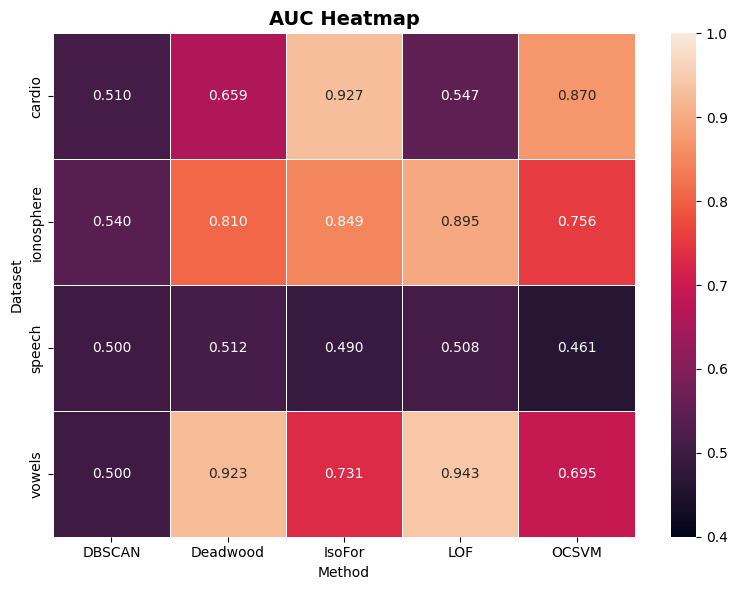

In [82]:
fig, ax = plt.subplots(figsize=(8, 6))

auc_pivot = results_df["AUC"].unstack("Method").fillna(0)
sns.heatmap(
    auc_pivot,
    annot=True,
    fmt=".3f",
    vmin=0.4,
    vmax=1.0,
    ax=ax,
    linewidths=0.5
)

ax.set_title("AUC Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

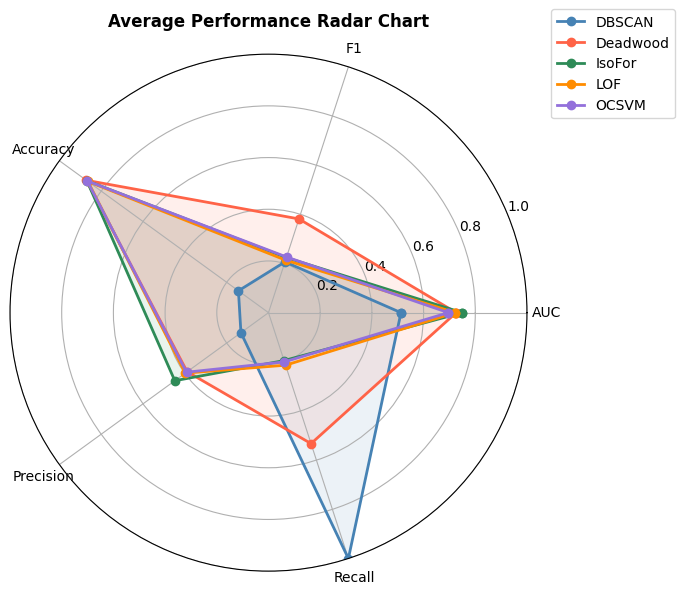

In [78]:
avg_auc = results_df["AUC"].groupby("Method").mean()
avg_f1  = results_df["F1"].groupby("Method").mean()
avg_acc = results_df["Accuracy"].groupby("Method").mean()
avg_prec = results_df["Precision"].groupby("Method").mean()
avg_rec  = results_df["Recall"].groupby("Method").mean()

method_names = list(avg_auc.index)
categories = ["AUC", "F1", "Accuracy", "Precision", "Recall"]
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_title("Average Performance Radar Chart", fontweight="bold", pad=20)

colors = ["steelblue", "tomato", "seagreen", "darkorange", "mediumpurple"]

for i, method in enumerate(method_names):
    values = [
        avg_auc[method],
        avg_f1[method],
        avg_acc[method],
        avg_prec[method],
        avg_rec[method]
    ]
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, label=method, color=colors[i])
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

We are going to evaluate algorithms on two-dimensional data and visualize it.

In [67]:
results_2d = []

for name, info in datasets_2d.items():
    X, y = load_2d_dataset(info["data"], info["labels"])

    methods = {
        "OCSVM": run_ocsvm,
        "IsoFor": run_isofor,
        "LOF": run_lof,
        "DBSCAN": run_dbscan,
        "Deadwood": run_deadwood
    }

    for method_name, method in methods.items():
        scores, preds = method(X)
        metrics = evaluate(y, preds, scores)
        metrics["Dataset"] = name
        metrics["Method"] = method_name
        results_2d.append(metrics)

results_2d_df = pd.DataFrame(results_2d).groupby(["Dataset", "Method"]).mean().sort_index(ascending=False)
results_2d_df

AUC  Accuracy  Precision    Recall        F1
Dataset     Method                                                     
zigzag      OCSVM     0.864400  0.867857   0.315789  0.200000  0.244898
            LOF       0.996000  0.935714   0.928571  0.433333  0.590909
            IsoFor    0.969200  0.900000   0.571429  0.266667  0.363636
            Deadwood  0.986000  0.975000   0.810811  1.000000  0.895522
            DBSCAN    0.500000  0.892857   0.000000  0.000000  0.000000
ring        OCSVM     0.909133  0.950485   0.301887  0.533333  0.385542
            LOF       0.998967  0.978641   0.576923  1.000000  0.731707
            IsoFor    1.000000  0.978641   0.576923  1.000000  0.731707
            Deadwood  0.985000  0.970874   0.500000  1.000000  0.666667
            DBSCAN    0.500000  0.970874   0.000000  0.000000  0.000000
flame       OCSVM     0.744883  0.920833   0.181818  0.166667  0.173913
            LOF       0.754020  0.916667   0.166667  0.166667  0.166667
            IsoFor    0.384503  0.916667   0.166667  0.166667  0.166667
            Deadwood  0.671053  0.825000   0.142857  0.500000  0.222222
            DBSCAN    0.583333  0.958333   1.000000  0.166667  0.285714
aggregation OCSVM          NaN  0.947970   0.000000  0.000000  0.000000
            LOF            NaN  0.949239   0.000000  0.000000  0.000000
            IsoFor         NaN  0.949239   0.000000  0.000000  0.000000
            Deadwood       NaN  0.857868   0.000000  0.000000  0.000000
            DBSCAN         NaN  1.000000   0.000000  0.000000  0.000000

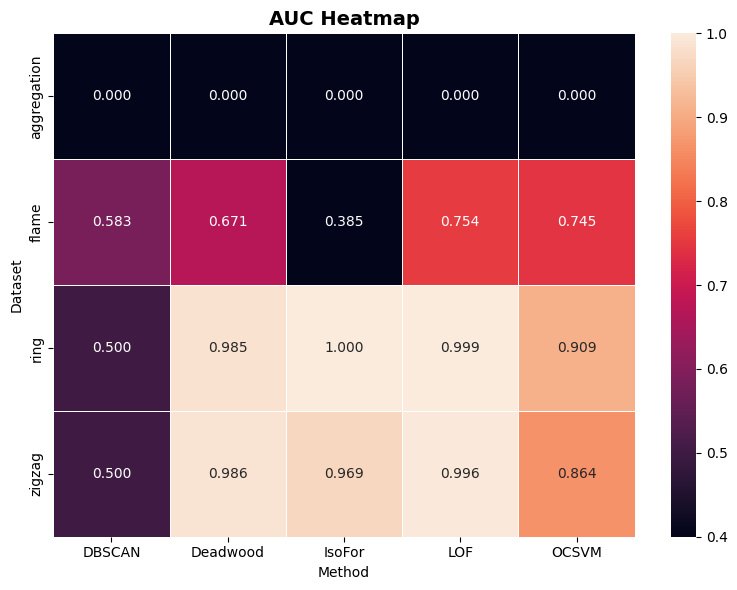

In [83]:
fig, ax = plt.subplots(figsize=(8, 6))

auc_pivot = results_2d_df["AUC"].unstack("Method").fillna(0)
sns.heatmap(
    auc_pivot,
    annot=True,
    fmt=".3f",
    vmin=0.4,
    vmax=1.0,
    ax=ax,
    linewidths=0.5
)

ax.set_title("AUC Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

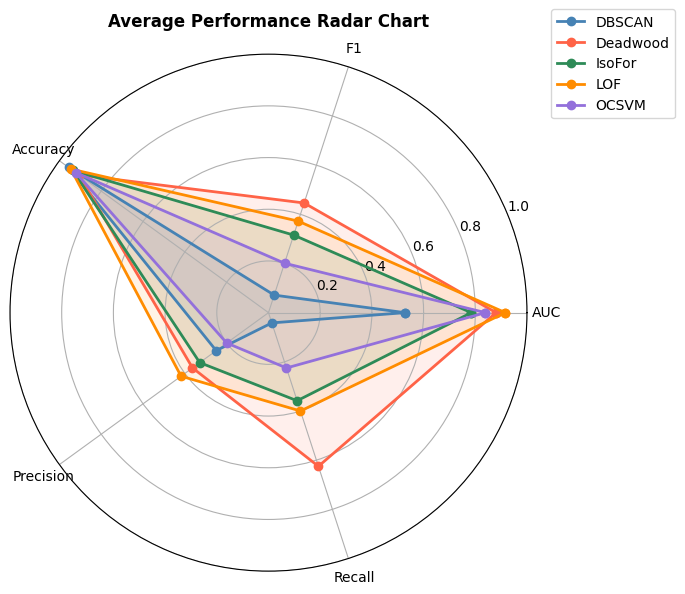

In [79]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

avg_auc = results_2d_df["AUC"].groupby("Method").mean()
avg_f1  = results_2d_df["F1"].groupby("Method").mean()
avg_acc = results_2d_df["Accuracy"].groupby("Method").mean()
avg_prec = results_2d_df["Precision"].groupby("Method").mean()
avg_rec  = results_2d_df["Recall"].groupby("Method").mean()

method_names = list(avg_auc.index)
categories = ["AUC", "F1", "Accuracy", "Precision", "Recall"]
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_title("Average Performance Radar Chart", fontweight="bold", pad=20)

colors = ["steelblue", "tomato", "seagreen", "darkorange", "mediumpurple"]

for i, method in enumerate(method_names):
    values = [
        avg_auc[method],
        avg_f1[method],
        avg_acc[method],
        avg_prec[method],
        avg_rec[method]
    ]
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, label=method, color=colors[i])
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

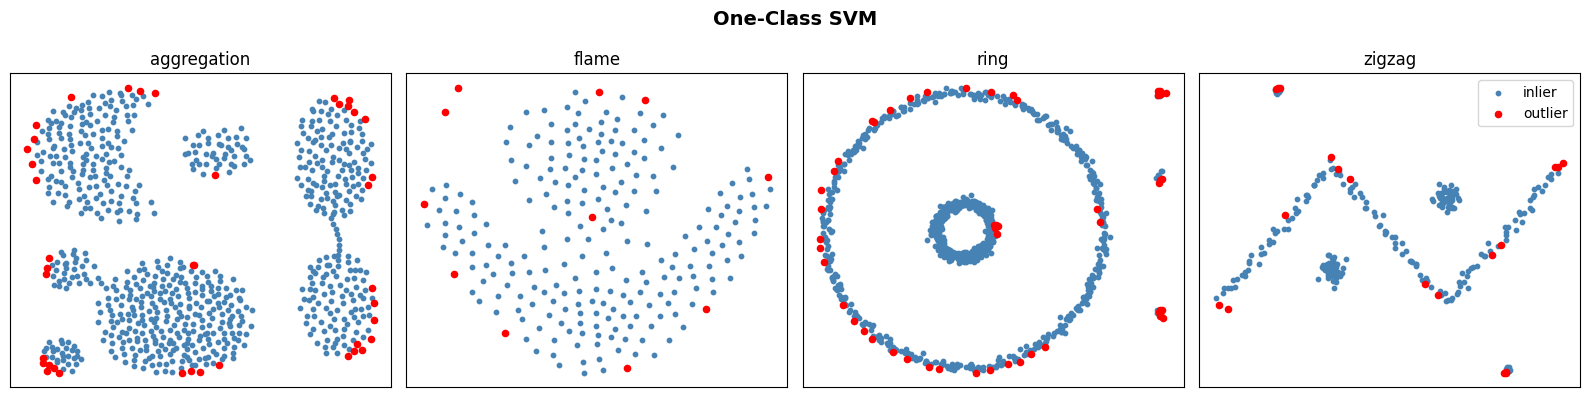

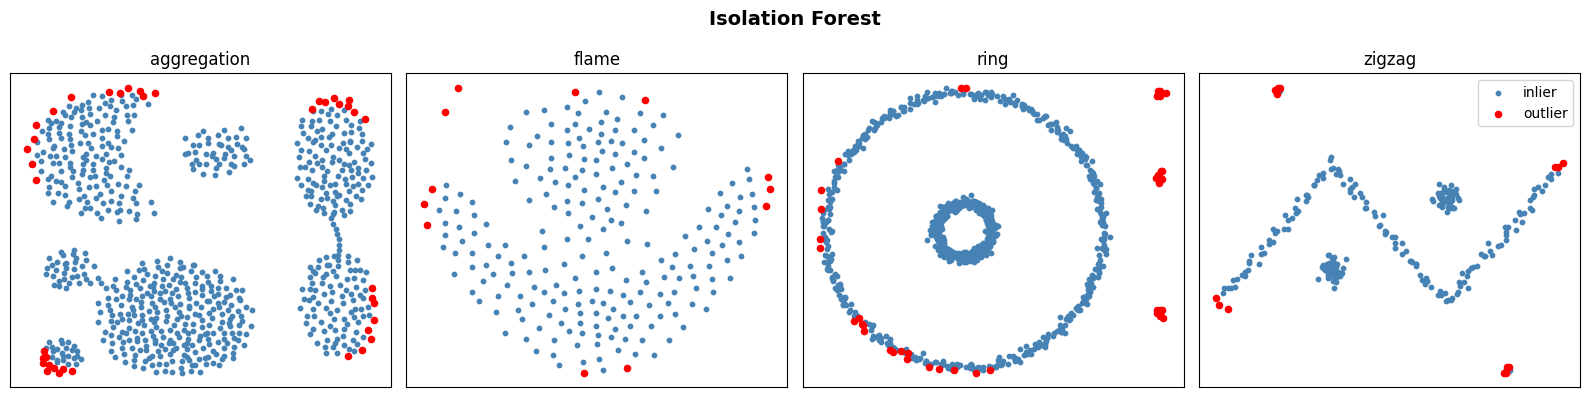

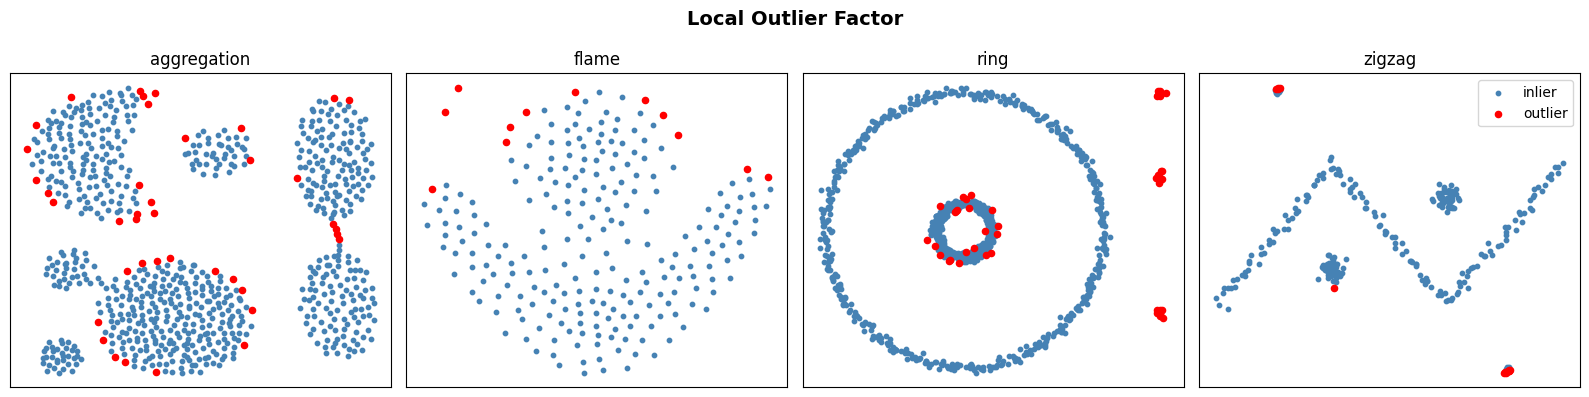

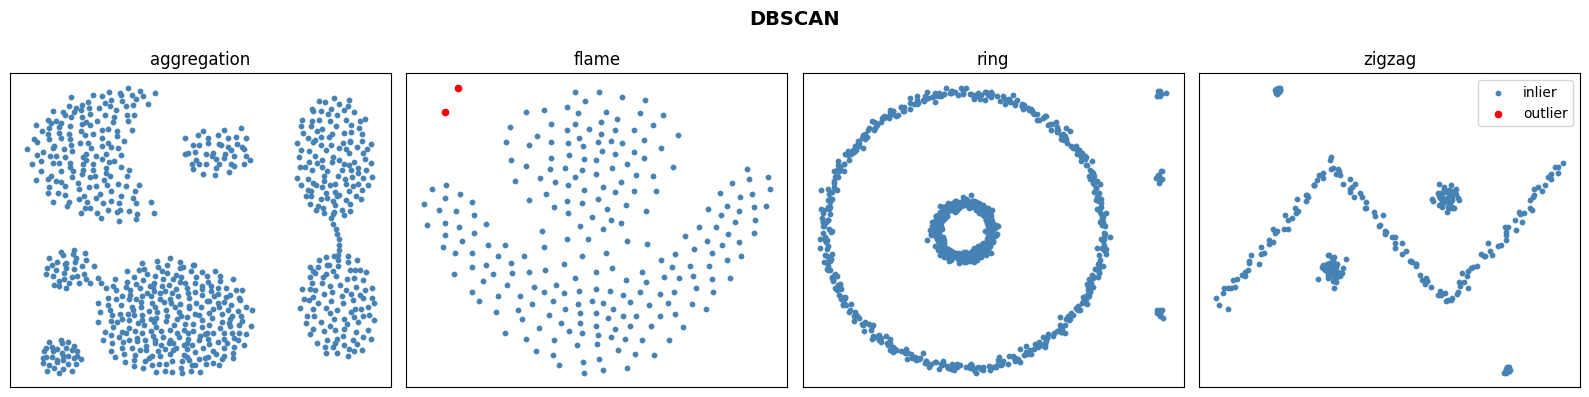

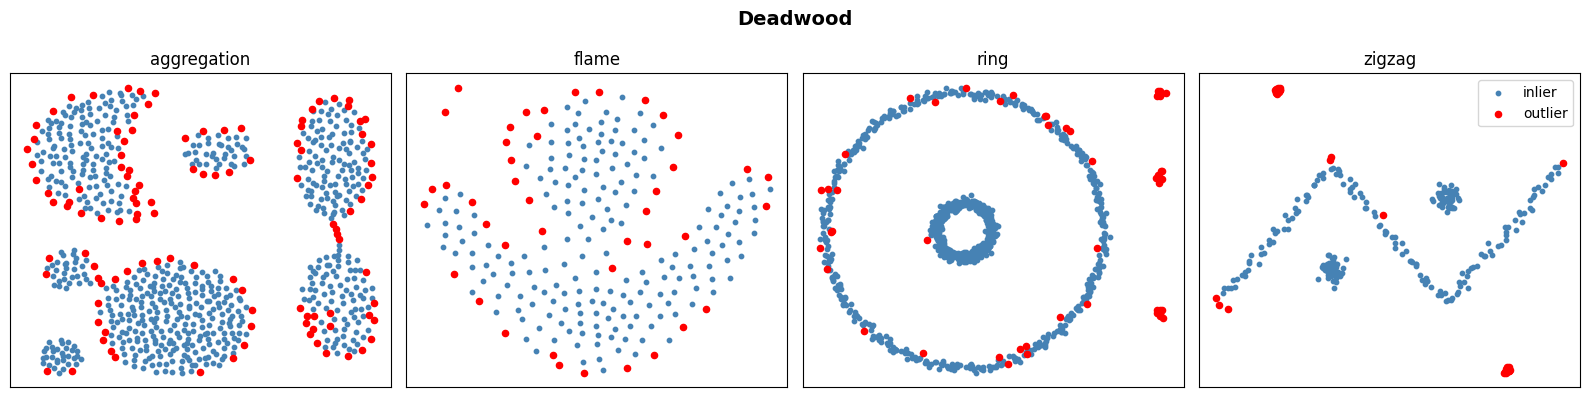

In [86]:
plot_2d_results(datasets_2d, "One-Class SVM", run_ocsvm)
print("\n")
plot_2d_results(datasets_2d, "Isolation Forest", run_isofor)
print("\n")
plot_2d_results(datasets_2d, "Local Outlier Factor", run_lof)
print("\n")
plot_2d_results(datasets_2d, "DBSCAN", run_dbscan)
print("\n")
plot_2d_results(datasets_2d, "Deadwood", run_deadwood)

### Hyperparameter Analysis

We are going to perform hyperparameter analysis to find best performing parameters for each model and to identify algorithm sensitivity to each hyperparameter.

#### One-Class SVM

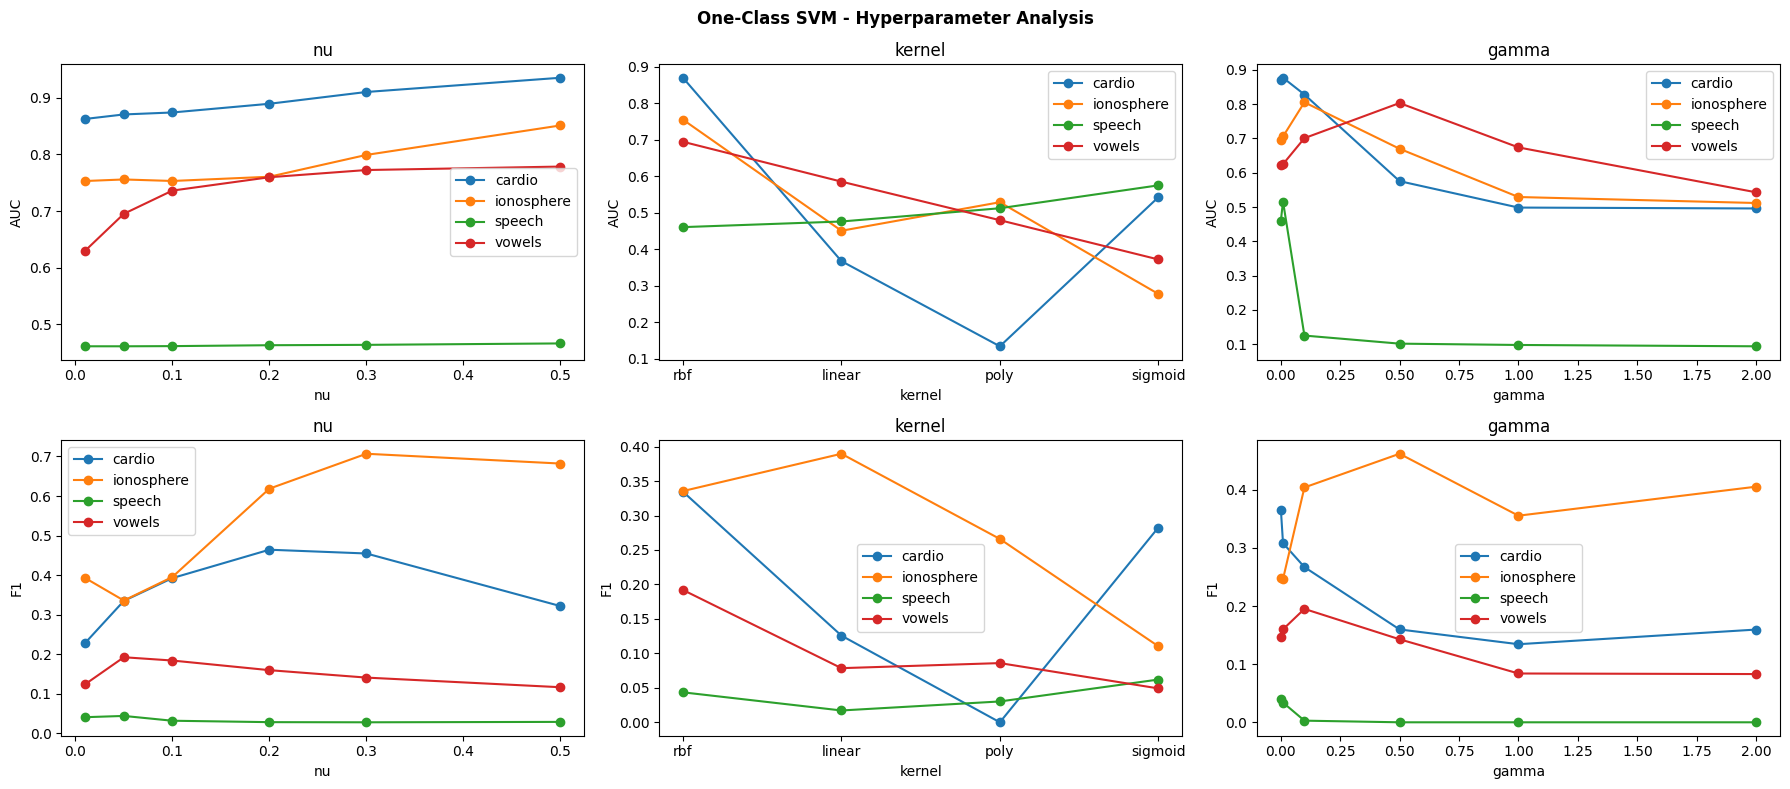

In [ ]:
nu_values = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
kernels = ["rbf", "linear", "poly", "sigmoid"]
gamma_values = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle("One-Class SVM - Hyperparameter Analysis", fontweight="bold")

for name, path in datasets.items():
    X, y = load_mat_dataset(path)

    aucs, f1s = [], []
    for nu in nu_values:
        scores, preds = run_ocsvm(X, nu=nu)
        metrics = evaluate(y, preds, scores)
        aucs.append(metrics["AUC"])
        f1s.append(metrics["F1"])
    axes[0, 0].plot(nu_values, aucs, marker="o", label=name)
    axes[1, 0].plot(nu_values, f1s, marker="o", label=name)

axes[0, 0].set_title("nu")
axes[0, 0].set_xlabel("nu")
axes[0, 0].set_ylabel("AUC")
axes[0, 0].legend()
axes[1, 0].set_title("nu")
axes[1, 0].set_xlabel("nu")
axes[1, 0].set_ylabel("F1")
axes[1, 0].legend()

for name, path in datasets.items():
    X, y = load_mat_dataset(path)

    aucs, f1s = [], []
    for k in kernels:
        scores, preds = run_ocsvm(X, kernel=k)
        metrics = evaluate(y, preds, scores)
        aucs.append(metrics["AUC"])
        f1s.append(metrics["F1"])
    axes[0, 1].plot(kernels, aucs, marker="o", label=name)
    axes[1, 1].plot(kernels, f1s, marker="o", label=name)

axes[0, 1].set_title("kernel")
axes[0, 1].set_xlabel("kernel")
axes[0, 1].set_ylabel("AUC")
axes[0, 1].legend()
axes[1, 1].set_title("kernel")
axes[1, 1].set_xlabel("kernel")
axes[1, 1].set_ylabel("F1")
axes[1, 1].legend()

for name, path in datasets.items():
    X, y = load_mat_dataset(path)

    aucs, f1s = [], []
    for g in gamma_values:
        scores, preds = run_ocsvm(X, gamma=g)
        metrics = evaluate(y, preds, scores)
        aucs.append(metrics["AUC"])
        f1s.append(metrics["F1"])
    axes[0, 2].plot(gamma_values, aucs, marker="o", label=name)
    axes[1, 2].plot(gamma_values, f1s, marker="o", label=name)

axes[0, 2].set_title("gamma")
axes[0, 2].set_xlabel("gamma")
axes[0, 2].set_ylabel("AUC")
axes[0, 2].legend()
axes[1, 2].set_title("gamma")
axes[1, 2].set_xlabel("gamma")
axes[1, 2].set_ylabel("F1")
axes[1, 2].legend()

plt.tight_layout()
plt.show()

In [63]:
scores, preds = run_ocsvm(X, nu=0.05, gamma='scale', kernel='rbf')
metrics = evaluate(y, preds, scores)
results_df = pd.DataFrame(metrics, index=["One-Class SVM"])
results_df

,AUC,Accuracy,Precision,Recall,F1
One-Class SVM,0.695064,0.930632,0.16,0.24,0.192


#### Isolation Forest

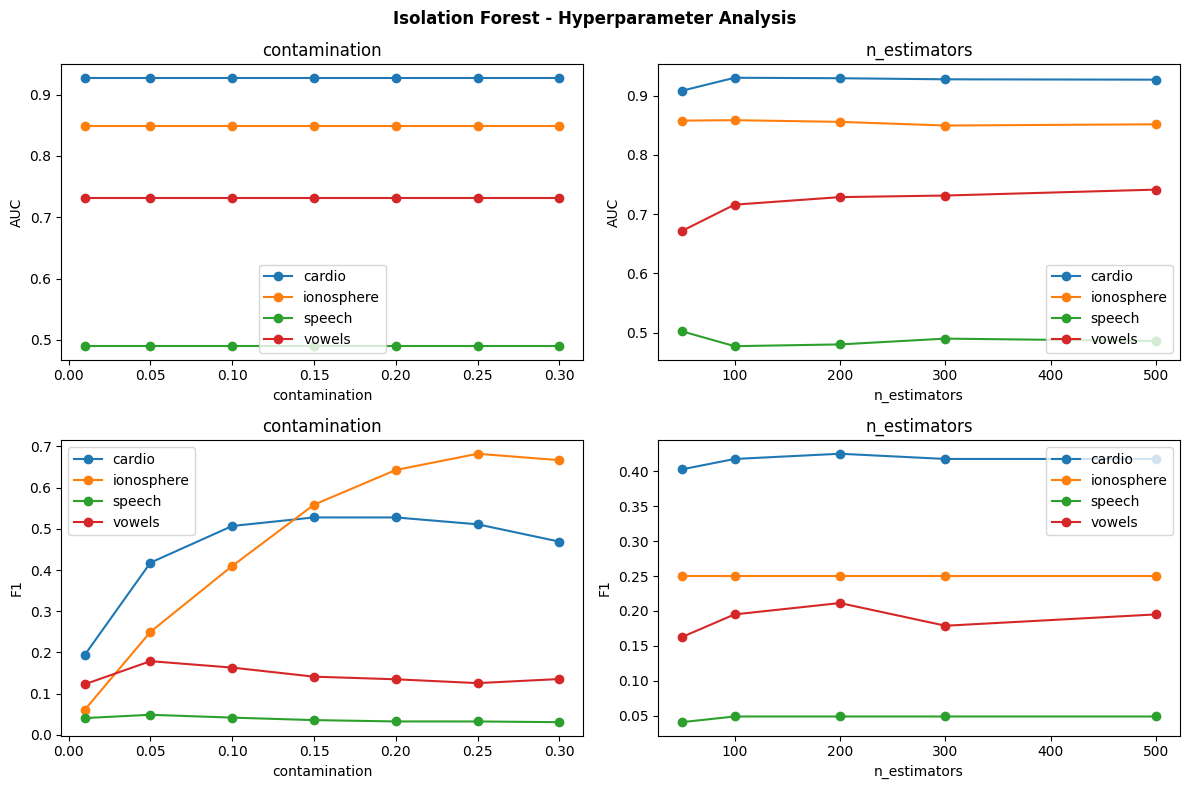

In [ ]:
contaminations = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
n_estimators_list = [50, 100, 200, 300, 500]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Isolation Forest - Hyperparameter Analysis", fontweight="bold")

for name, path in datasets.items():
    X, y = load_mat_dataset(path)

    aucs, f1s = [], []
    for c in contaminations:
        scores, preds = run_isofor(X, contamination=c)
        metrics = evaluate(y, preds, scores)
        aucs.append(metrics["AUC"])
        f1s.append(metrics["F1"])
    axes[0, 0].plot(contaminations, aucs, marker="o", label=name)
    axes[1, 0].plot(contaminations, f1s, marker="o", label=name)

axes[0, 0].set_title("contamination")
axes[0, 0].set_xlabel("contamination")
axes[0, 0].set_ylabel("AUC")
axes[0, 0].legend()
axes[1, 0].set_title("contamination")
axes[1, 0].set_xlabel("contamination")
axes[1, 0].set_ylabel("F1")
axes[1, 0].legend()

for name, path in datasets.items():
    X, y = load_mat_dataset(path)

    aucs, f1s = [], []
    for n in n_estimators_list:
        scores, preds = run_isofor(X, n_estimators=n)
        metrics = evaluate(y, preds, scores)
        aucs.append(metrics["AUC"])
        f1s.append(metrics["F1"])
    axes[0, 1].plot(n_estimators_list, aucs, marker="o", label=name)
    axes[1, 1].plot(n_estimators_list, f1s, marker="o", label=name)

axes[0, 1].set_title("n_estimators")
axes[0, 1].set_xlabel("n_estimators")
axes[0, 1].set_ylabel("AUC")
axes[0, 1].legend()
axes[1, 1].set_title("n_estimators")
axes[1, 1].set_xlabel("n_estimators")
axes[1, 1].set_ylabel("F1")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [ ]:
scores, preds = run_isofor(X, contamination=0.2, n_estimators=200, random_state=42)
metrics = evaluate(y, preds, scores)
results_df = pd.DataFrame(metrics, index=["Isolation Forest"])
results_df

,AUC,Accuracy,Precision,Recall,F1
Isolation Forest,0.728592,0.796016,0.075601,0.44,0.129032


#### Local Outlier Factor

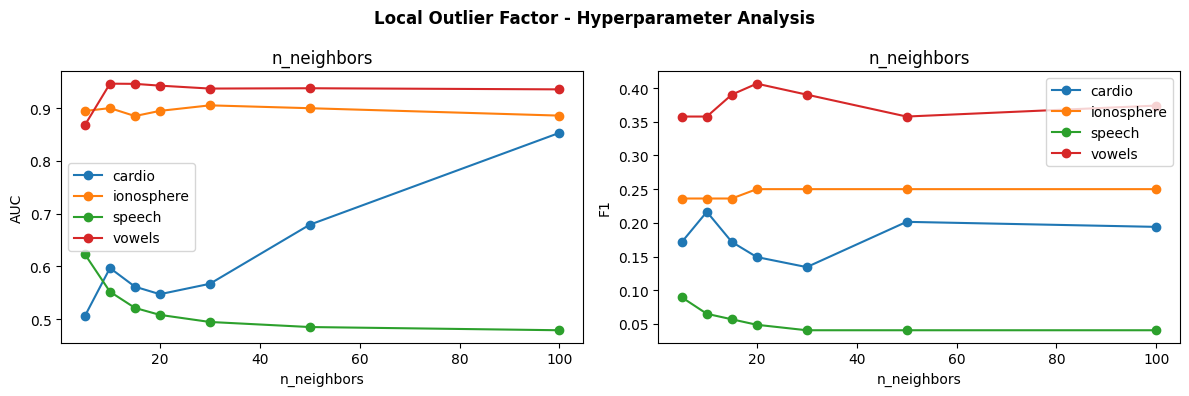

In [ ]:
n_neighbors_list = [5, 10, 15, 20, 30, 50, 100]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Local Outlier Factor - Hyperparameter Analysis", fontweight="bold")

for name, path in datasets.items():
    X, y = load_mat_dataset(path)

    aucs, f1s = [], []
    for n in n_neighbors_list:
        scores, preds = run_lof(X, n_neighbors=n)
        metrics = evaluate(y, preds, scores)
        aucs.append(metrics["AUC"])
        f1s.append(metrics["F1"])
    axes[0].plot(n_neighbors_list, aucs, marker="o", label=name)
    axes[1].plot(n_neighbors_list, f1s, marker="o", label=name)

axes[0].set_title("n_neighbors")
axes[0].set_xlabel("n_neighbors")
axes[0].set_ylabel("AUC")
axes[0].legend()
axes[1].set_title("n_neighbors")
axes[1].set_xlabel("n_neighbors")
axes[1].set_ylabel("F1")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
scores, preds = run_lof(X, n_neighbors=15, contamination=0.05)
metrics = evaluate(y, preds, scores)
results_df = pd.DataFrame(metrics, index=["Isolation Forest"])
results_df

,AUC,Accuracy,Precision,Recall,F1
Isolation Forest,0.946373,0.948489,0.328767,0.48,0.390244


#### DBSCAN

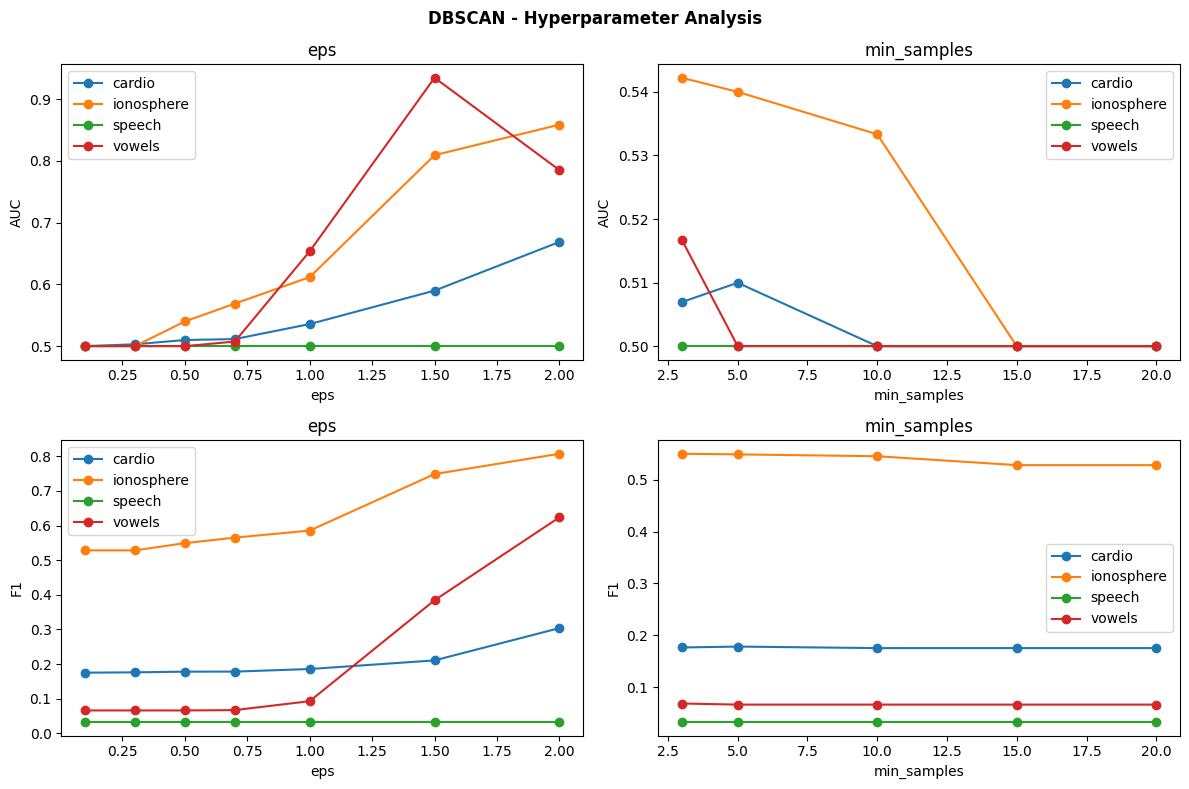

In [ ]:
eps_values = [0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
min_samples_list = [3, 5, 10, 15, 20]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("DBSCAN - Hyperparameter Analysis", fontweight="bold")

for name, path in datasets.items():
    X, y = load_mat_dataset(path)

    aucs, f1s = [], []
    for e in eps_values:
        scores, preds = run_dbscan(X, eps=e)
        metrics = evaluate(y, preds, scores)
        aucs.append(metrics["AUC"])
        f1s.append(metrics["F1"])
    axes[0, 0].plot(eps_values, aucs, marker="o", label=name)
    axes[1, 0].plot(eps_values, f1s, marker="o", label=name)

axes[0, 0].set_title("eps")
axes[0, 0].set_xlabel("eps")
axes[0, 0].set_ylabel("AUC")
axes[0, 0].legend()
axes[1, 0].set_title("eps")
axes[1, 0].set_xlabel("eps")
axes[1, 0].set_ylabel("F1")
axes[1, 0].legend()

for name, path in datasets.items():
    X, y = load_mat_dataset(path)

    aucs, f1s = [], []
    for m in min_samples_list:
        scores, preds = run_dbscan(X, min_samples=m)
        metrics = evaluate(y, preds, scores)
        aucs.append(metrics["AUC"])
        f1s.append(metrics["F1"])
    axes[0, 1].plot(min_samples_list, aucs, marker="o", label=name)
    axes[1, 1].plot(min_samples_list, f1s, marker="o", label=name)

axes[0, 1].set_title("min_samples")
axes[0, 1].set_xlabel("min_samples")
axes[0, 1].set_ylabel("AUC")
axes[0, 1].legend()
axes[1, 1].set_title("min_samples")
axes[1, 1].set_xlabel("min_samples")
axes[1, 1].set_ylabel("F1")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [ ]:
scores, preds = run_dbscan(X, eps=1.5, min_samples=3)
metrics = evaluate(y, preds, scores)
results_df = pd.DataFrame(metrics, index=["DBSCAN"])
results_df

,AUC,Accuracy,Precision,Recall,F1
Isolation Forest,0.878265,0.96978,0.541667,0.78,0.639344


#### Deadwood

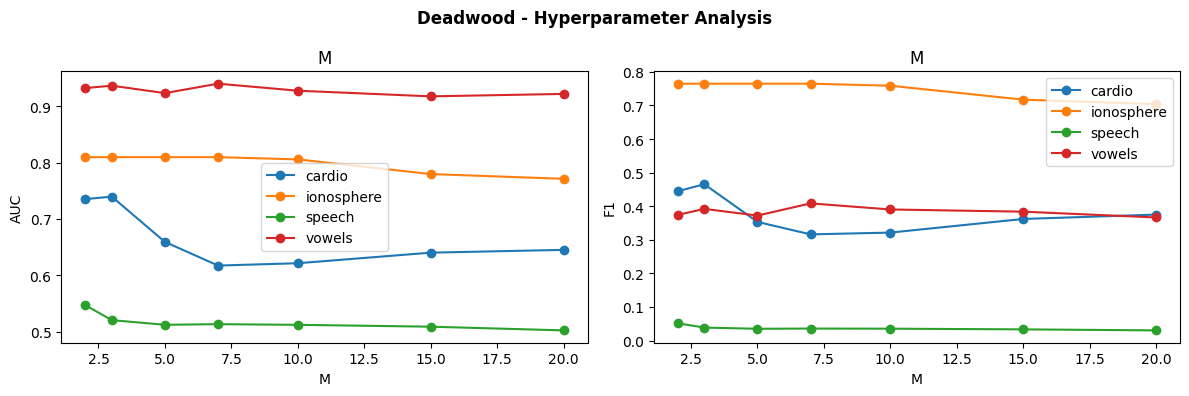

In [ ]:
m_values = [2, 3, 5, 7, 10, 15, 20]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Deadwood - Hyperparameter Analysis", fontweight="bold")

for name, path in datasets.items():
    X, y = load_mat_dataset(path)

    aucs, f1s = [], []
    for m in m_values:
        scores, preds = run_deadwood(X, M=m)
        metrics = evaluate(y, preds, scores)
        aucs.append(metrics["AUC"])
        f1s.append(metrics["F1"])
    axes[0].plot(m_values, aucs, marker="o", label=name)
    axes[1].plot(m_values, f1s, marker="o", label=name)

axes[0].set_title("M")
axes[0].set_xlabel("M")
axes[0].set_ylabel("AUC")
axes[0].legend()
axes[1].set_title("M")
axes[1].set_xlabel("M")
axes[1].set_ylabel("F1")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
scores, preds = run_deadwood(X, M=3)
metrics = evaluate(y, preds, scores)
results_df = pd.DataFrame(metrics, index=["DBSCAN"])
results_df

,AUC,Accuracy,Precision,Recall,F1
DBSCAN,0.936302,0.895604,0.245,0.98,0.392


## Verification Task

In [81]:
from sklearn.preprocessing import RobustScaler

test_df = pd.read_csv("test_data.csv")
X_test = test_df.values

scaler = RobustScaler()
X_test_scaled = scaler.fit_transform(X_test)

Q1 = np.percentile(X_test_scaled, 25, axis=0)
Q3 = np.percentile(X_test_scaled, 75, axis=0)
IQR = Q3 - Q1
outlier_mask = np.any((X_test_scaled < Q1 - 1.5 * IQR) | (X_test_scaled > Q3 + 1.5 * IQR), axis=1)
contamination_estimate = np.clip(outlier_mask.mean(), 0.01, 0.4)
print(f"Estimated contamination: {contamination_estimate:.3f}")

_, preds_iso  = run_isofor(X_test_scaled, contamination=contamination_estimate)
_, preds_lof  = run_lof(X_test_scaled, contamination=contamination_estimate)
_, preds_svm  = run_ocsvm(X_test_scaled, nu=contamination_estimate)

votes = preds_iso + preds_lof + preds_svm
final_preds = (votes >= 2).astype(int)

print(f"Outliers detected: {np.sum(final_preds)} ({100*np.mean(final_preds):.1f}%)")

pd.DataFrame({"class": final_preds}).to_csv("test_labels.csv", index=False)
print("Saved test_labels.csv")

Estimated contamination: 0.071
Outliers detected: 214 (6.2%)
Saved test_labels.csv
